In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from collections import defaultdict

df = pd.read_csv("titles.csv", sep = ",")
print("Filas: "+ str(df.shape[0])+ "Columnas: "+str(df.shape[1]))

print("Tamaño en memoria: "+str(round(df.memory_usage(deep = True).sum()/ 1024*2, 2)))

#Numero de valores unicos por columna
df.nunique()

#Porcentaje de nulos por columna
(df.isnull().mean()*100).round(2)

df["duration"].head(10)

# Columnas tipo texto
cols_obj = df.select_dtypes(include='object').columns
print("Columnas object: " + str(cols_obj.tolist()))

#Como la mayoria tienen mas de 50 valores unicos, no conviene cambiarlos a categoricos

df = df.drop(columns = ["duration"])
df.sample(5)


Filas: 16000Columnas: 18
Tamaño en memoria: 31868.72
Columnas object: ['type', 'title', 'director', 'cast', 'country', 'date_added', 'genres', 'language', 'description']


C:\Users\gomez\AppData\Local\Temp\ipykernel_30612\3865503987.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_obj = df.select_dtypes(include='object').columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,genres,language,description,popularity,vote_count,vote_average,budget,revenue
12542,543504,Movie,Detective vs. Sleuths,Wai Ka-Fai,"Sean Lau Ching-Wan, Raymond Lam Fung, Charlene...",Hong Kong,2022-07-08,2022,6.7,"Action, Crime, Mystery, Thriller",cn,When Hong Kong is rocked by multiple gruesome ...,12.582,82,6.7,0,105500000
1934,84479,Movie,The Invader,Nicolas Provost,"Issaka Sawadogo, Stefania Rocca, John Flanders...",Belgium,2011-11-23,2011,5.6,Drama,fr,An African immigrant living illegally in Belgi...,4.705,19,5.6,0,0
8811,531736,Movie,"To Each, Her Own",Myriam Aziza,"Sarah Stern, Jean-Christophe Folly, Julia Piat...",France,2018-06-24,2018,5.1,"Comedy, Romance",fr,Just as Simone works up the courage to tell he...,8.077,180,5.1,0,0
12819,752564,Movie,Maigret,Patrice Leconte,"Gérard Depardieu, Anne Loiret, Aurore Clément,...","Belgium, France",2022-02-23,2022,5.8,"Mystery, Drama",fr,"In Paris, a young girl is found dead in a Pari...",9.021,260,5.8,7000000,5934907
2223,137548,Movie,Gladiators of Rome,Iginio Straffi,"Luca Argentero, Laura Chiatti, Belén Rodríguez...",Italy,2012-10-18,2012,5.7,"Animation, Family",it,"A new hero is born in this hilarious, animated...",14.067,140,5.7,40000000,10079201


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  str    
 2   title         16000 non-null  str    
 3   director      15868 non-null  str    
 4   cast          15796 non-null  str    
 5   country       15534 non-null  str    
 6   date_added    16000 non-null  str    
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   genres        15893 non-null  str    
 10  language      16000 non-null  str    
 11  description   15868 non-null  str    
 12  popularity    16000 non-null  float64
 13  vote_count    16000 non-null  int64  
 14  vote_average  16000 non-null  float64
 15  budget        16000 non-null  int64  
 16  revenue       16000 non-null  int64  
dtypes: float64(3), int64(5), str(9)
memory usage: 2.1 MB


In [2]:
#EJERCICIO 1
df_blocbuster = df[(df["budget"]> 10000000) & (df["popularity"]>10)]
print("Numero de titulos: ", len(df_blocbuster))
df_blocbuster.nunique()
rating_medio = df_blocbuster["rating"].mean()
print("rating medio: ", rating_medio)
df_blocbuster.groupby("title")["rating"].mean()

Numero de titulos:  2211
rating medio:  6.538614654002714


title
'71                           6.803
10 Cloverfield Lane           6.991
12 Strong                     6.334
12 Years a Slave              7.936
127 Hours                     7.100
                              ...  
Zoolander 2                   4.900
Zootopia                      7.700
Zulu                          6.700
mother!                       7.000
xXx: Return of Xander Cage    6.135
Name: rating, Length: 2204, dtype: float64

In [3]:
#EJERCICIO 2
df.nunique()
duplicados = df.duplicated(subset=["title", "release_year"])
print("Numero de duplicados: "+ str(duplicados.sum()))
print("Porcentaje de duplicados", round(((duplicados.sum()/len(df))*100), 2))

Numero de duplicados: 37
Porcentaje de duplicados 0.23


In [4]:
#Para eliminar los duplicados si quisiesemos quedarnos con los true habria que eliminar ~
df = df[~duplicados]
len(df)

15963

In [5]:
df["country_clean"] = df["country"].astype(str).str.split(",").str[0].str.strip()

df.groupby("country_clean")[["title", "budget", "revenue", "rating" ]].agg({"title" : "count", "budget": "mean",
    "revenue": "mean", "rating": "mean"})
df_resultado = df.groupby("country_clean").agg(
    Numero_de_titulos=("title", "count"),
    Budget_medio=("budget", "mean"),
    Revenue_medio=("revenue", "mean"),
    Rating_medio=("rating", "mean")
).round(2)
df_resultado

,Numero_de_titulos,Budget_medio,Revenue_medio,Rating_medio
country_clean,,,,
Afghanistan,2,0.00,74335.50,6.80
Albania,2,8000000.00,0.00,5.51
Algeria,4,7500000.00,867621.75,6.80
Angola,1,2600000.00,0.00,5.70
Argentina,111,1261156.36,2442138.22,6.31
...,...,...,...,...
United States Minor Outlying Islands,1,0.00,0.00,10.00
United States of America,5689,14867830.67,42519091.24,5.98
Uruguay,4,1500.00,0.00,6.32


In [6]:
#EJERCICIO 4
print(len(df))
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
estrenos_por_anio = df["release_year"].dropna().value_counts().sort_index()


15963


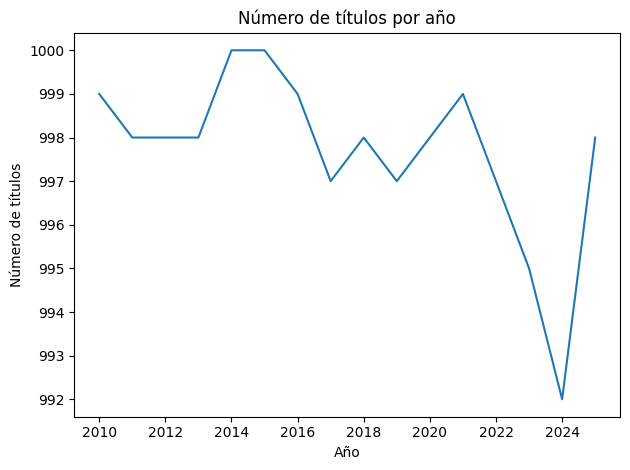

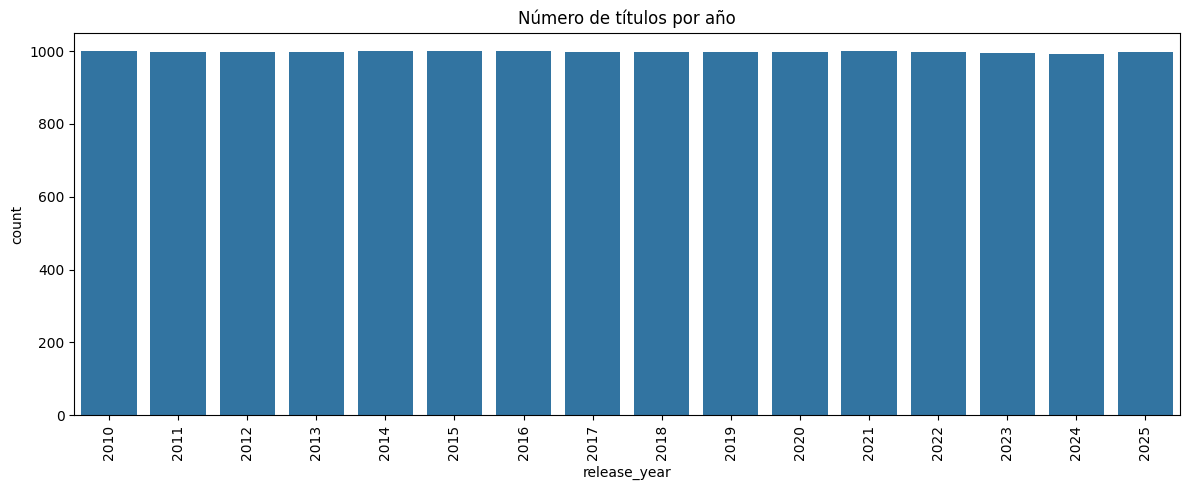

In [ ]:
estrenos_por_anio.plot(kind="line", title="Número de títulos por año")
plt.xlabel("Año")
plt.ylabel("Número de títulos")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.countplot(data=df, x="release_year", order=sorted(df["release_year"].dropna().unique()))
plt.xticks(rotation=90)
plt.title("Número de títulos por año")
plt.tight_layout()
plt.show()
#Primer grafico por los eliminados en duplicados

In [19]:
#EJERCICIO 5
df["decade"] = (df["release_year"]//10)*10
df.head(5)
tabla_cruzada = pd.crosstab(df["country"], df["decade"])
tabla_cruzada

decade,2010,2020
country,,
"Afghanistan, France",1,0
"Afghanistan, United Kingdom, Germany, France",1,0
"Albania, Jordan, Thailand, United States of America",0,1
"Albania, United States of America",0,1
"Algeria, Belgium, France",1,0
...,...,...
Venezuela,4,1
"Venezuela, Argentina",1,0
"Venezuela, Mexico",1,0


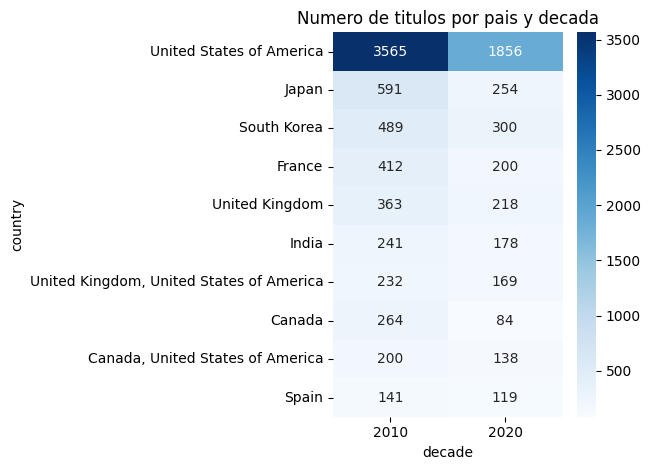

In [20]:
#PARTE 2
top_10 = df["country"].value_counts().head(10).index
tabla_top = tabla_cruzada.loc[top_10]

sns.heatmap(tabla_top,annot = True, cmap = "Blues", fmt = "d")
plt.title("Numero de titulos por pais y decada")
plt.tight_layout()
plt.show()


In [45]:
#EJERCICIO 6
palabras_clave = ["war", "love", "life", "death"]

for i in palabras_clave:
    df[i] = df["description"].str.contains(r"\b"+i+r"\b", case = False, na = False)

df.sample(10)
(df[palabras_clave].mean())*100 
df_porcentajes = (df.groupby("country_clean")[palabras_clave].mean())*100
top_10_paises = df["country_clean"].value_counts().head(10).index
top_10_paises
df_porcentajes.loc[top_10_paises]

,war,love,life,death
country_clean,,,,
United States of America,3.018073,6.176522,14.739428,3.790139
United Kingdom,4.857143,6.285714,16.380952,3.714286
France,2.815534,10.097087,19.320388,3.980583
Canada,2.360515,7.188841,12.553648,3.111588
Japan,7.002188,5.908096,9.628009,3.719912
South Korea,2.078240,14.669927,11.124694,2.567237
India,3.680982,13.701431,14.928425,2.453988
Belgium,4.782609,11.304348,21.304348,3.913043
China,4.578313,7.710843,13.975904,2.891566


In [90]:
#EJERCICIO 7
df_subconjunto = df[["rating", "popularity", "budget", "revenue"]].dropna()

X=df_subconjunto.drop("rating", axis = 1)
y=df_subconjunto["rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
variables_numericas = ["popularity", "budget", "revenue"]

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[variables_numericas])
X_test_num = scaler.transform(X_test[variables_numericas])



In [91]:
from sklearn.metrics import r2_score, classification_report
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_num, y_train)
pred_lr = modelo_lr.predict(X_test_num)

print("R2 : "+str(r2_score(y_test, pred_lr)))
#El lo hace diferente pero el resultado es el mismo


R2 : 0.014934394063832124


In [84]:
#EJERCICIO 8
df["buena_valoracion"] = df["rating"]>7

X = df[["budget", "revenue", "popularity"]]
y = df["buena_valoracion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_knn = KNeighborsClassifier(n_neighbors= 5)
modelo_knn.fit(X_train_scaled, y_train)
y_pred = modelo_knn.predict(X_test_scaled)

print("Accuracy: "+ str(accuracy_score(y_test, y_pred)))

Accuracy: 0.7559375


<Axes: >

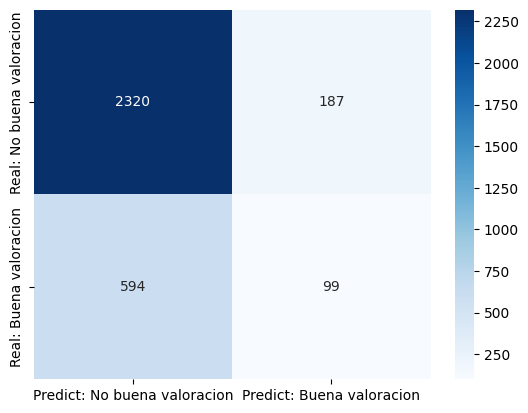

In [85]:
matriz = confusion_matrix(y_test, y_pred)
confusion_df = pd.DataFrame(
    matriz,
    index = ["Real: No buena valoracion", "Real: Buena valoracion"],
    columns=["Predict: No buena valoracion", "Predict: Buena valoracion"]
)


sns.heatmap(confusion_df, annot = True, fmt = 'd', cmap = "Blues")

In [ ]:
#Con regresion logistica
modelo_logisticregresion = LogisticRegression(max_iter=1000)
modelo_logisticregresion.fit(X_train_scaled, y_train)
pred_log = modelo_logisticregresion.predict(X_test_scaled)

print("Regresion logistica")
print(confusion_matrix(y_test, pred_log))
print(classification_report(y_test, pred_log))

#El mio bastante mal fijarse en el original, ya que selecciona peli
#peliculas solo, quita los valores nulos y no pone

Regresion logistica
[[2488   19]
 [ 670   23]]
              precision    recall  f1-score   support

       False       0.79      0.99      0.88      2507
        True       0.55      0.03      0.06       693

    accuracy                           0.78      3200
   macro avg       0.67      0.51      0.47      3200
weighted avg       0.74      0.78      0.70      3200



In [ ]:
#EJERCICIO 9
df["primeras_palabras"] = df["title"].astype(str).str.split().str[0]
#Usar mucho el value_counts!!!!!
df["primeras_palabras"].value_counts().head(10)

primeras_palabras
The      2650
A         324
My        155
I          85
Love       84
In         65
Black      58
All        57
One        56
No         46
Name: count, dtype: int64

In [23]:
#EJERCICIO 10
from sklearn.cluster import KMeans 
from sklearn.decomposition import PCA
df_cluster = df[["budget", "revenue", "popularity", "rating"]].dropna()
columnas = df_cluster.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans= KMeans(n_clusters=4, random_state=24, n_init=10)
df_cluster["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components= 2)
X_pca = pca.fit_transform(X_scaled)

print("Numero de titulos por cluster")
df_cluster["cluster_kmeans"].value_counts().sort_index()

Numero de titulos por cluster


cluster_kmeans
0     1034
1    14529
2       10
3      427
Name: count, dtype: int64

In [24]:
pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns = columnas)

,budget,revenue,popularity,rating
0,1.406615e+06,1.191860e+05,11.341651,0.314439
1,5.064770e+06,1.097642e+07,17.720938,6.332788
2,8.280000e+07,2.682937e+08,2155.952700,7.046800
3,1.508201e+08,5.365964e+08,82.907145,6.785063


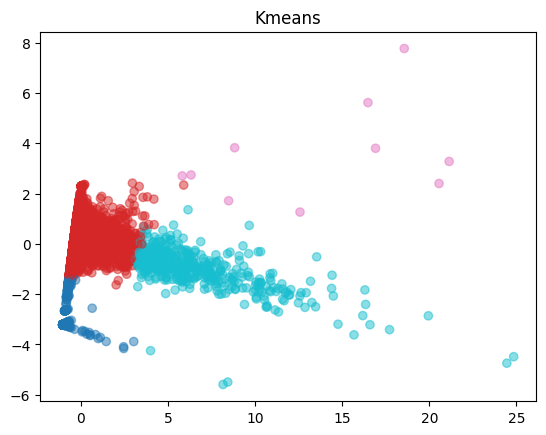

In [25]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df_cluster["cluster_kmeans"], cmap = "tab10", alpha = 0.5)
plt.title("Kmeans")
plt.show()